# Evidence-hit F1 analysis for `base_ev.json` vs `pred_ev.json`

This notebook batch-pairs files in `results/evidence`, extracts criterion-level `used_chunk_ids`, and computes evidence-hit Precision / Recall / F1.

## Metric definition

For each matched criterion:

- **TP** = predicted chunk ids that also appear in base
- **FP** = predicted chunk ids not in base
- **FN** = base chunk ids missed by prediction

Then:

- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1** = 2PR / (P + R)



In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

DATA_DIR = Path('results/evidence')
BASE_SUFFIX = '_base_ev.json'
PRED_SUFFIX = '_pred_ev.json'

# pred.general corresponds to base.General + base.Applicant
SECTION_MAPPING = {
    'general': ['General', 'Applicant'],
    'proposed_research': ['Proposed research'],
    'training_development': ['Training and development'],
    'sites_support': ['Sites and support'],
    'wpcc': ['Working with people and communities'],
    'application_form': ['Application Form'],
}



In [26]:
def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def parse_pred_sections(pred_obj: dict) -> dict:
    parsed = {}
    for sec_name, sec_value in pred_obj.items():
        if isinstance(sec_value, str):
            parsed[sec_name] = json.loads(sec_value)
        else:
            parsed[sec_name] = sec_value
    return parsed


def extract_criteria_from_base(base_obj: dict, section_names: list[str]) -> list[dict]:
    rows = []
    for sec in section_names:
        sec_obj = base_obj.get(sec, {})
        if not isinstance(sec_obj, dict):
            continue
        for crit_name, crit_obj in sec_obj.items():
            if isinstance(crit_obj, dict) and 'used_chunk_ids' in crit_obj:
                rows.append({
                    'base_section': sec,
                    'base_criterion': crit_name,
                    'base_chunks': set(crit_obj.get('used_chunk_ids', []) or []),
                })
    return rows


def extract_criteria_from_pred(pred_sec_obj: dict) -> list[dict]:
    rows = []
    for crit_name, crit_obj in pred_sec_obj.items():
        if isinstance(crit_obj, dict) and 'used_chunk_ids' in crit_obj:
            rows.append({
                'pred_criterion': crit_name,
                'pred_chunks': set(crit_obj.get('used_chunk_ids', []) or []),
            })
    return rows


def score_pair(base_chunks: set, pred_chunks: set) -> dict:
    tp = len(base_chunks & pred_chunks)
    fp = len(pred_chunks - base_chunks)
    fn = len(base_chunks - pred_chunks)

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if pd.notna(precision) and pd.notna(recall) and (precision + recall) else np.nan

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def score_case(case_id: str, base_path: Path, pred_path: Path) -> tuple[pd.DataFrame, list[str]]:
    base_obj = load_json(base_path)
    pred_obj = parse_pred_sections(load_json(pred_path))

    rows = []
    warnings = []

    for pred_sec, base_secs in SECTION_MAPPING.items():
        base_rows = extract_criteria_from_base(base_obj, base_secs)
        pred_rows = extract_criteria_from_pred(pred_obj.get(pred_sec, {}))

        if len(base_rows) != len(pred_rows):
            warnings.append(
                f'[{case_id}] section {pred_sec}: base={len(base_rows)} criteria, pred={len(pred_rows)} criteria'
            )

        n = min(len(base_rows), len(pred_rows))
        for i in range(n):
            b = base_rows[i]
            p = pred_rows[i]
            metric = score_pair(b['base_chunks'], p['pred_chunks'])

            rows.append({
                'case_id': case_id,
                'pred_section': pred_sec,
                'base_section': b['base_section'],
                'pair_index_in_section': i + 1,
                'base_criterion': b['base_criterion'],
                'pred_criterion': p['pred_criterion'],
                'base_chunk_count': len(b['base_chunks']),
                'pred_chunk_count': len(p['pred_chunks']),
                **metric,
            })

    return pd.DataFrame(rows), warnings



In [27]:
# Pair files by case id
base_paths = {p.name.replace(BASE_SUFFIX, ''): p for p in DATA_DIR.glob(f'*{BASE_SUFFIX}')}
pred_paths = {p.name.replace(PRED_SUFFIX, ''): p for p in DATA_DIR.glob(f'*{PRED_SUFFIX}')}

case_ids = sorted(set(base_paths) & set(pred_paths))
missing_base = sorted(set(pred_paths) - set(base_paths))
missing_pred = sorted(set(base_paths) - set(pred_paths))

print(f'Found {len(case_ids)} matched cases: {case_ids}')
if missing_base:
    print('Missing base files for:', missing_base)
if missing_pred:
    print('Missing pred files for:', missing_pred)



Found 3 matched cases: ['IC00001', 'IC00011', 'IC00047']


In [28]:
all_rows = []
all_warnings = []

for cid in case_ids:
    df_case, warnings = score_case(cid, base_paths[cid], pred_paths[cid])
    all_rows.append(df_case)
    all_warnings.extend(warnings)

criterion_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

print(f'Criterion-level rows: {len(criterion_df)}')
if all_warnings:
    print('Warnings:')
    for w in all_warnings:
        print('-', w)



Criterion-level rows: 93


In [29]:
criterion_df.head(12)


,case_id,pred_section,base_section,pair_index_in_section,base_criterion,pred_criterion,base_chunk_count,pred_chunk_count,tp,fp,fn,precision,recall,f1
0,IC00001,general,General,1,common_characteristics_of_good_applications,g.1,10,5,3,2,7,0.60,0.300000,0.400000
1,IC00001,general,General,2,tell_us_why_you_need_this_award,g.2,9,4,4,0,5,1.00,0.444444,0.615385
2,IC00001,general,Applicant,3,Relevant Research Experience and Training,g.3,8,5,5,0,3,1.00,0.625000,0.769231
3,IC00001,general,Applicant,4,Impactful Research Outputs and Outcomes,g.4,9,6,6,0,3,1.00,0.666667,0.800000
4,IC00001,general,Applicant,5,Trajectory Towards Research Leadership,g.5,9,5,3,2,6,0.60,0.333333,0.428571
5,IC00001,general,Applicant,6,Commitment to Practitioner-Academic Career (if applicable),g.6,6,5,4,1,2,0.80,0.666667,0.727273
6,IC00001,proposed_research,Proposed research,1,Quality of the Plain English Summary,pr.1,10,4,4,0,6,1.00,0.400000,0.571429
7,IC00001,proposed_research,Proposed research,2,Evidence Review Quality & Relevance,pr.2,10,4,4,0,6,1.00,0.400000,0.571429
8,IC00001,proposed_research,Proposed research,3,Research Scope & Award Appropriateness,pr.3,8,4,2,2,6,0.50,0.250000,0.333333
9,IC00001,proposed_research,Proposed research,4,Research Design & Methodological Rigor,pr.4,14,4,4,0,10,1.00,0.285714,0.444444


In [30]:
# Case-level aggregates

def micro_scores(df: pd.DataFrame) -> pd.Series:
    tp = df['tp'].sum()
    fp = df['fp'].sum()
    fn = df['fn'].sum()

    p = tp / (tp + fp) if (tp + fp) else np.nan
    r = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (2 * p * r / (p + r)) if pd.notna(p) and pd.notna(r) and (p + r) else np.nan

    return pd.Series({
        'criteria_n': len(df),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'micro_precision': p,
        'micro_recall': r,
        'micro_f1': f1,
        'macro_precision': df['precision'].mean(),
        'macro_recall': df['recall'].mean(),
        'macro_f1': df['f1'].mean(),
    })

case_summary = criterion_df.groupby('case_id', as_index=False).apply(micro_scores, include_groups=False)
case_summary = case_summary.sort_values('case_id').reset_index(drop=True)
case_summary



,case_id,criteria_n,tp,fp,fn,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
0,IC00001,31.0,104.0,29.0,107.0,0.781955,0.492891,0.604651,0.804966,0.573563,0.662716
1,IC00011,31.0,51.0,9.0,33.0,0.850000,0.607143,0.708333,0.873656,0.695159,0.757893
2,IC00047,31.0,96.0,26.0,107.0,0.786885,0.472906,0.590769,0.783602,0.522657,0.629744


In [31]:
overall = micro_scores(criterion_df).to_frame().T
overall.index = ['overall']
overall


,criteria_n,tp,fp,fn,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
overall,93.0,251.0,64.0,247.0,0.796825,0.504016,0.617466,0.820913,0.596308,0.683684


In [32]:
section_summary = (
    criterion_df
    .groupby('pred_section', as_index=False)
    .agg(
        criteria_n=('f1', 'size'),
        mean_precision=('precision', 'mean'),
        mean_recall=('recall', 'mean'),
        mean_f1=('f1', 'mean'),
    )
    .sort_values('mean_f1', ascending=False)
)
section_summary


,pred_section,criteria_n,mean_precision,mean_recall,mean_f1
0,application_form,9,1.000000,0.851852,0.888889
4,training_development,9,0.912963,0.777249,0.832049
3,sites_support,12,0.881944,0.721230,0.769567
1,general,18,0.892130,0.562492,0.662797
5,wpcc,18,0.648092,0.596503,0.638510
2,proposed_research,27,0.769231,0.417721,0.559125


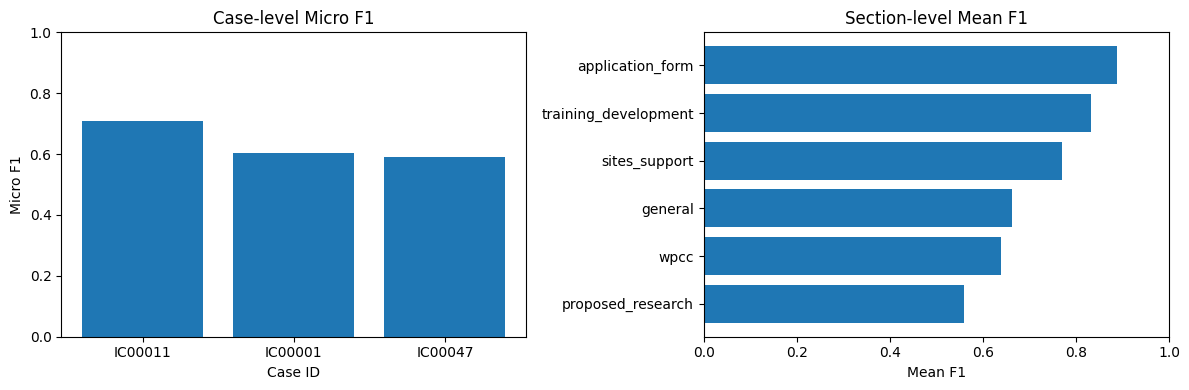

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

case_plot = case_summary.sort_values('micro_f1', ascending=False)
axes[0].bar(case_plot['case_id'], case_plot['micro_f1'])
axes[0].set_title('Case-level Micro F1')
axes[0].set_xlabel('Case ID')
axes[0].set_ylabel('Micro F1')
axes[0].set_ylim(0, 1)

sec_plot = section_summary.sort_values('mean_f1', ascending=False)
axes[1].barh(sec_plot['pred_section'], sec_plot['mean_f1'])
axes[1].set_title('Section-level Mean F1')
axes[1].set_xlabel('Mean F1')
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()



In [34]:
# Worst matched criteria (lowest F1)
criterion_df.sort_values(['f1', 'case_id', 'pred_section']).head(20)


,case_id,pred_section,base_section,pair_index_in_section,base_criterion,pred_criterion,base_chunk_count,pred_chunk_count,tp,fp,fn,precision,recall,f1
72,IC00047,proposed_research,Proposed research,5,"Potential Impact on Patients, Public, and Health Services",pr.5,7,3,1,2,6,0.333333,0.142857,0.200000
73,IC00047,proposed_research,Proposed research,6,Engagement with People & Communities,pr.6,10,4,2,2,8,0.500000,0.200000,0.285714
8,IC00001,proposed_research,Proposed research,3,Research Scope & Award Appropriateness,pr.3,8,4,2,2,6,0.500000,0.250000,0.333333
41,IC00011,proposed_research,Proposed research,5,"Potential Impact on Patients, Public, and Health Services",pr.5,4,2,1,1,3,0.500000,0.250000,0.333333
85,IC00047,wpcc,Working with people and communities,2,Diversity and Inclusivity of the Research Team,wp.2,3,3,1,2,2,0.333333,0.333333,0.333333
31,IC00011,general,General,1,common_characteristics_of_good_applications,g.1,5,1,1,0,4,1.000000,0.200000,0.333333
76,IC00047,proposed_research,Proposed research,9,Inclusive Research Design,pr.9,7,4,2,2,5,0.500000,0.285714,0.363636
18,IC00001,sites_support,Sites and support,1,Track Record of the Contracting Organisation (and Partners),ss.1,12,4,3,1,9,0.750000,0.250000,0.375000
0,IC00001,general,General,1,common_characteristics_of_good_applications,g.1,10,5,3,2,7,0.600000,0.300000,0.400000
39,IC00011,proposed_research,Proposed research,3,Research Scope & Award Appropriateness,pr.3,3,2,1,1,2,0.500000,0.333333,0.400000
